In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import copy
import csv
import seaborn as sns
import pandas as pd
import cv2
from PIL import Image
from sklearn.metrics import (classification_report,confusion_matrix,precision_score,
                                recall_score,f1_score,roc_auc_score)

In [5]:
#  Chuẩn bị dữ liệu

data_dir = "/kaggle/input/chest-x-ray-combined/Processed_XRay_Dataset"  

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Ảnh đã resize sẵn, chỉ cần normalize
data_transforms = {
    'train': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'test': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
}

# Load dữ liệu theo cấu trúc thư mục
image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val', 'test']
}

# Bật shuffle cho train
dataloaders = {
    'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=16, shuffle=True, num_workers=2),
    'val': torch.utils.data.DataLoader(image_datasets['val'], batch_size=16, shuffle=False, num_workers=2),
    'test': torch.utils.data.DataLoader(image_datasets['test'], batch_size=16, shuffle=False, num_workers=2),
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
num_classes = len(class_names)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"🟢 Classes: {class_names} | Total classes: {num_classes}")

🟢 Classes: ['NORMAL', 'PNEUMONIA'] | Total classes: 2


In [7]:
# Vẽ biểu đồ loss / acc

def plot(val_list, train_list, typ,model_name, out_dir="/kaggle/working"):
    plt.title(f"{typ} after epoch: {len(train_list)}")
    plt.xlabel("Epoch")
    plt.ylabel(typ)
    plt.plot(range(len(train_list)), train_list, color="r", label=f"Train {typ}")
    plt.plot(range(len(val_list)), val_list, color="b", label=f"Val {typ}")
    plt.legend()
    
    filename = f"{model_name}_{typ}.png"
    plt.savefig(os.path.join(out_dir, filename))
    plt.close()

In [8]:
# Hàm xuất xác suất dự đoán, nhãn, và đánh giá model
def evaluate_and_export(model, dataloaders, class_names, model_name="resnet50", out_dir="/kaggle/working"):
    
    device = next(model.parameters()).device  # tự lấy device đang dùng
    model.eval()

    # Xuất xác suất (probabilities)
    
    def export_probabilities(dataloader, phase):
        model.eval()
        probs, filenames, labels_all = [], [], []

        with torch.no_grad():
            for i, (inputs, labels) in enumerate(dataloader):
                inputs = inputs.to(device)
                outputs = model(inputs)
                prob = torch.nn.functional.softmax(outputs, dim=1)
                probs.append(prob.cpu().numpy())
                labels_all.extend(labels.tolist())

                # Lấy tên file
                paths = [dataloader.dataset.samples[i + j][0] for j in range(inputs.size(0))]
                filenames.extend([os.path.basename(p) for p in paths])

        probs = np.vstack(probs)
        out_path = os.path.join(out_dir, f"{model_name}_{phase}_probs.csv")
        label_path = os.path.join(out_dir, f"{model_name}_{phase}_labels.csv")

        # Ghi file xác suất
        with open(out_path, 'w', newline='') as f:
            writer = csv.writer(f)
            header = [f"class_{c}" for c in class_names] + ["filename"]
            writer.writerow(header)
            for i in range(len(filenames)):
                writer.writerow(list(probs[i]) + [filenames[i]])

        # Ghi file nhãn
        with open(label_path, 'w', newline='') as f:
            writer = csv.writer(f)
            for i in range(len(filenames)):
                writer.writerow([filenames[i], labels_all[i]])

        print(f"✅ Saved {model_name} {phase} probabilities to {out_path}")

    # Gọi xuất cho cả 3 phase
    for phase in ['train', 'val', 'test']:
        export_probabilities(dataloaders[phase], phase)


    # Đánh giá model trên test
    
    print(f"\n🔍 Evaluating {model_name} on test set...")
    all_labels, all_preds = [], []

    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    
    # Accuracy, Precision, Recall, F1
    print(f"\n📈 Classification Report - {model_name}:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f"Pred: {c}" for c in class_names],
                yticklabels=[f"True: {c}" for c in class_names])
    plt.title(f'Confusion Matrix - {model_name} (Test Set)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


In [10]:
# Hàm train model (có Early Stopping)

def train_model(model, criterion, optimizer, scheduler, num_epochs=20, patience=3, model_name="resnet50_pneumonia"):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_loss = float('inf')
    counter = 0

    train_loss_gph, val_loss_gph = [], []
    train_acc_gph, val_acc_gph = [], []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print('-' * 25)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            # Lưu lại thông tin
            if phase == 'train':
                train_loss_gph.append(float(epoch_loss))
                train_acc_gph.append(float(epoch_acc))
            else:
                val_loss_gph.append(float(epoch_loss))
                val_acc_gph.append(float(epoch_acc))

            # Vẽ biểu đồ
            plot(val_loss_gph, train_loss_gph, "Loss",model_name)
            plot(val_acc_gph, train_acc_gph, "Accuracy",model_name)

            print(f"{phase} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            # ✅ Lưu model tốt nhất theo accuracy
            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save(model.state_dict(), f"/kaggle/working/{model_name}_best.pth")
                    print("✅ Model improved and saved!")

                # 🛑 Kiểm tra early stopping theo loss
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    counter = 0
                else:
                    counter += 1

                if counter >= patience:
                    print("⛔ Early stopping triggered.")
                    model.load_state_dict(best_model_wts)
                    time_elapsed = time.time() - since
                    print(f"Training stopped early in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")
                    print(f"Best val Acc: {best_acc:.4f}")
                    return model

    # Huấn luyện xong toàn bộ epoch
    time_elapsed = time.time() - since
    print(f"\n✅ Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model


In [12]:
# MODEL 1: ResNet50

model_resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze các layer đầu, chỉ fine-tune layer4 + fc
for name, param in model_resnet.named_parameters():
    if "layer4" not in name and "fc" not in name:
        param.requires_grad = False

# Thay head mới
num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, num_classes)
)
model_resnet = model_resnet.to(device)

# Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet.parameters()),
    lr=5e-5, weight_decay=1e-4
)
scheduler_resnet = lr_scheduler.StepLR(optimizer_resnet, step_size=5, gamma=0.5)

# Train ResNet50
model_resnet = train_model(
    model=model_resnet,
    criterion=criterion,
    optimizer=optimizer_resnet,
    scheduler=scheduler_resnet,
    num_epochs=20,
    patience=3,
    model_name="resnet50_pneumonia"
)


Epoch 1/20
-------------------------
train Loss: 0.2116 | Acc: 0.9204
val Loss: 0.1161 | Acc: 0.9612
✅ Model improved and saved!

Epoch 2/20
-------------------------
train Loss: 0.0644 | Acc: 0.9781
val Loss: 0.0803 | Acc: 0.9692
✅ Model improved and saved!

Epoch 3/20
-------------------------
train Loss: 0.0211 | Acc: 0.9955
val Loss: 0.1175 | Acc: 0.9692

Epoch 4/20
-------------------------
train Loss: 0.0180 | Acc: 0.9959
val Loss: 0.1062 | Acc: 0.9681

Epoch 5/20
-------------------------
train Loss: 0.0080 | Acc: 0.9984
val Loss: 0.1252 | Acc: 0.9681
⛔ Early stopping triggered.
Training stopped early in 4m 23s
Best val Acc: 0.9692


✅ Saved resnet50 train probabilities to /kaggle/working/resnet50_train_probs.csv
✅ Saved resnet50 val probabilities to /kaggle/working/resnet50_val_probs.csv
✅ Saved resnet50 test probabilities to /kaggle/working/resnet50_test_probs.csv

🔍 Evaluating resnet50 on test set...

📈 Classification Report - resnet50:
              precision    recall  f1-score   support

      NORMAL       0.96      0.97      0.96       238
   PNEUMONIA       0.99      0.98      0.99       642

    accuracy                           0.98       880
   macro avg       0.97      0.98      0.98       880
weighted avg       0.98      0.98      0.98       880



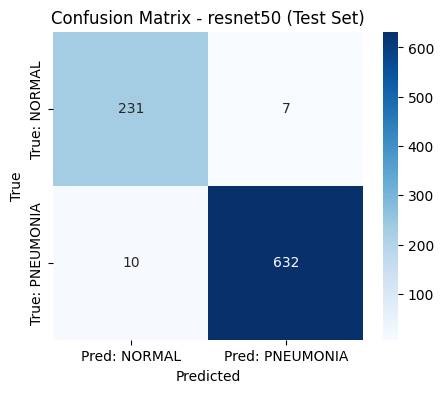

In [13]:
# Xuất xác suất dự đoán, nhãn, và đánh giá model ResNet50
evaluate_and_export(model_resnet, dataloaders, class_names, model_name="resnet50")

In [17]:
# MODEL 2: DenseNet169

model_dense = models.densenet169(weights=models.DenseNet169_Weights.DEFAULT)

# Freeze phần đầu, chỉ fine-tune denseblock4 + classifier
for name, param in model_dense.named_parameters():
    if "features.denseblock4" not in name and "classifier" not in name:
        param.requires_grad = False

# Thay classifier mới
num_ftrs = model_dense.classifier.in_features
model_dense.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, num_classes)
)
model_dense = model_dense.to(device)

# Loss, Optimizer, Scheduler
optimizer_dense = optim.Adam(
    filter(lambda p: p.requires_grad, model_dense.parameters()),
    lr=5e-5, weight_decay=1e-4
)
scheduler_dense = lr_scheduler.StepLR(optimizer_dense, step_size=5, gamma=0.5)

# Train DenseNet169
model_dense = train_model(
    model=model_dense,
    criterion=criterion,
    optimizer=optimizer_dense,
    scheduler=scheduler_dense,
    num_epochs=20,
    patience=3,
    model_name="densenet169_pneumonia"
)


Epoch 1/20
-------------------------
train Loss: 0.1502 | Acc: 0.9446
val Loss: 0.0815 | Acc: 0.9715
✅ Model improved and saved!

Epoch 2/20
-------------------------
train Loss: 0.0477 | Acc: 0.9843
val Loss: 0.0525 | Acc: 0.9829
✅ Model improved and saved!

Epoch 3/20
-------------------------
train Loss: 0.0212 | Acc: 0.9945
val Loss: 0.0470 | Acc: 0.9852
✅ Model improved and saved!

Epoch 4/20
-------------------------
train Loss: 0.0064 | Acc: 0.9989
val Loss: 0.0485 | Acc: 0.9886
✅ Model improved and saved!

Epoch 5/20
-------------------------
train Loss: 0.0070 | Acc: 0.9984
val Loss: 0.0449 | Acc: 0.9852

Epoch 6/20
-------------------------
train Loss: 0.0032 | Acc: 0.9991
val Loss: 0.0388 | Acc: 0.9886

Epoch 7/20
-------------------------
train Loss: 0.0013 | Acc: 0.9999
val Loss: 0.0515 | Acc: 0.9875

Epoch 8/20
-------------------------
train Loss: 0.0017 | Acc: 0.9998
val Loss: 0.0430 | Acc: 0.9897
✅ Model improved and saved!

Epoch 9/20
-------------------------
train 

✅ Saved densenet169 train probabilities to /kaggle/working/densenet169_train_probs.csv
✅ Saved densenet169 val probabilities to /kaggle/working/densenet169_val_probs.csv
✅ Saved densenet169 test probabilities to /kaggle/working/densenet169_test_probs.csv

🔍 Evaluating densenet169 on test set...

📈 Classification Report - densenet169:
              precision    recall  f1-score   support

      NORMAL       0.96      0.99      0.97       238
   PNEUMONIA       1.00      0.98      0.99       642

    accuracy                           0.99       880
   macro avg       0.98      0.99      0.98       880
weighted avg       0.99      0.99      0.99       880



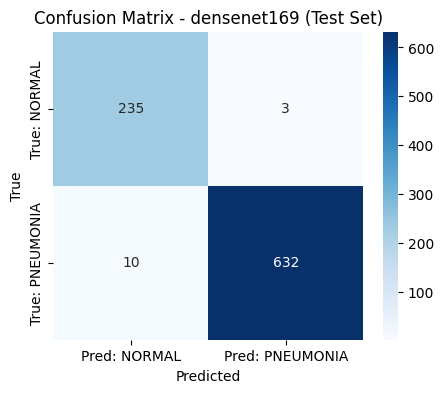

In [18]:
# Xuất xác suất dự đoán, nhãn, và đánh giá model DenseNet169
evaluate_and_export(model_dense, dataloaders, class_names, model_name="densenet169")

In [27]:
# MODEL 3: EfficientNet-B0

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Load EfficientNet-B0 với pretrained weights
model_efficient = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Thay classifier
num_ftrs = model_efficient.classifier[1].in_features
model_efficient.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, num_classes)
)
model_efficient = model_efficient.to(device)

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer_efficient = optim.Adam(
    filter(lambda p: p.requires_grad, model_efficient.parameters()),
    lr=5e-5, weight_decay=1e-4
)
scheduler_efficient = lr_scheduler.StepLR(optimizer_efficient, step_size=5, gamma=0.5)

# Train EfficientNet-B0
model_efficient = train_model(
    model=model_efficient,
    criterion=criterion,
    optimizer=optimizer_efficient,
    scheduler=scheduler_efficient,
    num_epochs=20,
    patience=3,
    model_name="efficientnetb0_pneumonia"
)


Epoch 1/20
-------------------------
train Loss: 0.1879 | Acc: 0.9304
val Loss: 0.0686 | Acc: 0.9783
✅ Model improved and saved!

Epoch 2/20
-------------------------
train Loss: 0.0724 | Acc: 0.9780
val Loss: 0.0481 | Acc: 0.9829
✅ Model improved and saved!

Epoch 3/20
-------------------------
train Loss: 0.0409 | Acc: 0.9871
val Loss: 0.0479 | Acc: 0.9829

Epoch 4/20
-------------------------
train Loss: 0.0237 | Acc: 0.9927
val Loss: 0.0404 | Acc: 0.9897
✅ Model improved and saved!

Epoch 5/20
-------------------------
train Loss: 0.0165 | Acc: 0.9946
val Loss: 0.0393 | Acc: 0.9863

Epoch 6/20
-------------------------
train Loss: 0.0082 | Acc: 0.9980
val Loss: 0.0333 | Acc: 0.9897

Epoch 7/20
-------------------------
train Loss: 0.0068 | Acc: 0.9979
val Loss: 0.0458 | Acc: 0.9863

Epoch 8/20
-------------------------
train Loss: 0.0085 | Acc: 0.9980
val Loss: 0.0532 | Acc: 0.9897

Epoch 9/20
-------------------------
train Loss: 0.0040 | Acc: 0.9991
val Loss: 0.0505 | Acc: 0.988

✅ Saved efficientnetb0 train probabilities to /kaggle/working/efficientnetb0_train_probs.csv
✅ Saved efficientnetb0 val probabilities to /kaggle/working/efficientnetb0_val_probs.csv
✅ Saved efficientnetb0 test probabilities to /kaggle/working/efficientnetb0_test_probs.csv

🔍 Evaluating efficientnetb0 on test set...

📈 Classification Report - efficientnetb0:
              precision    recall  f1-score   support

      NORMAL       0.99      0.99      0.99       238
   PNEUMONIA       1.00      1.00      1.00       642

    accuracy                           0.99       880
   macro avg       0.99      0.99      0.99       880
weighted avg       0.99      0.99      0.99       880



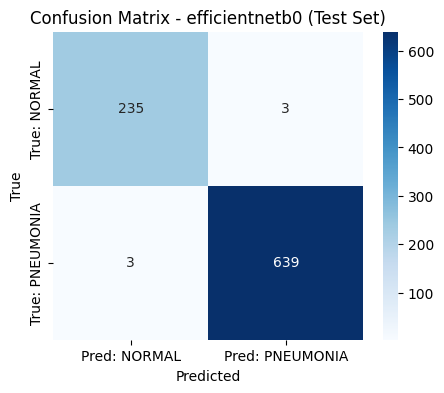

In [28]:
# Xuất xác suất dự đoán, nhãn và đánh giá model
evaluate_and_export(model_efficient, dataloaders, class_names, model_name="efficientnetb0")

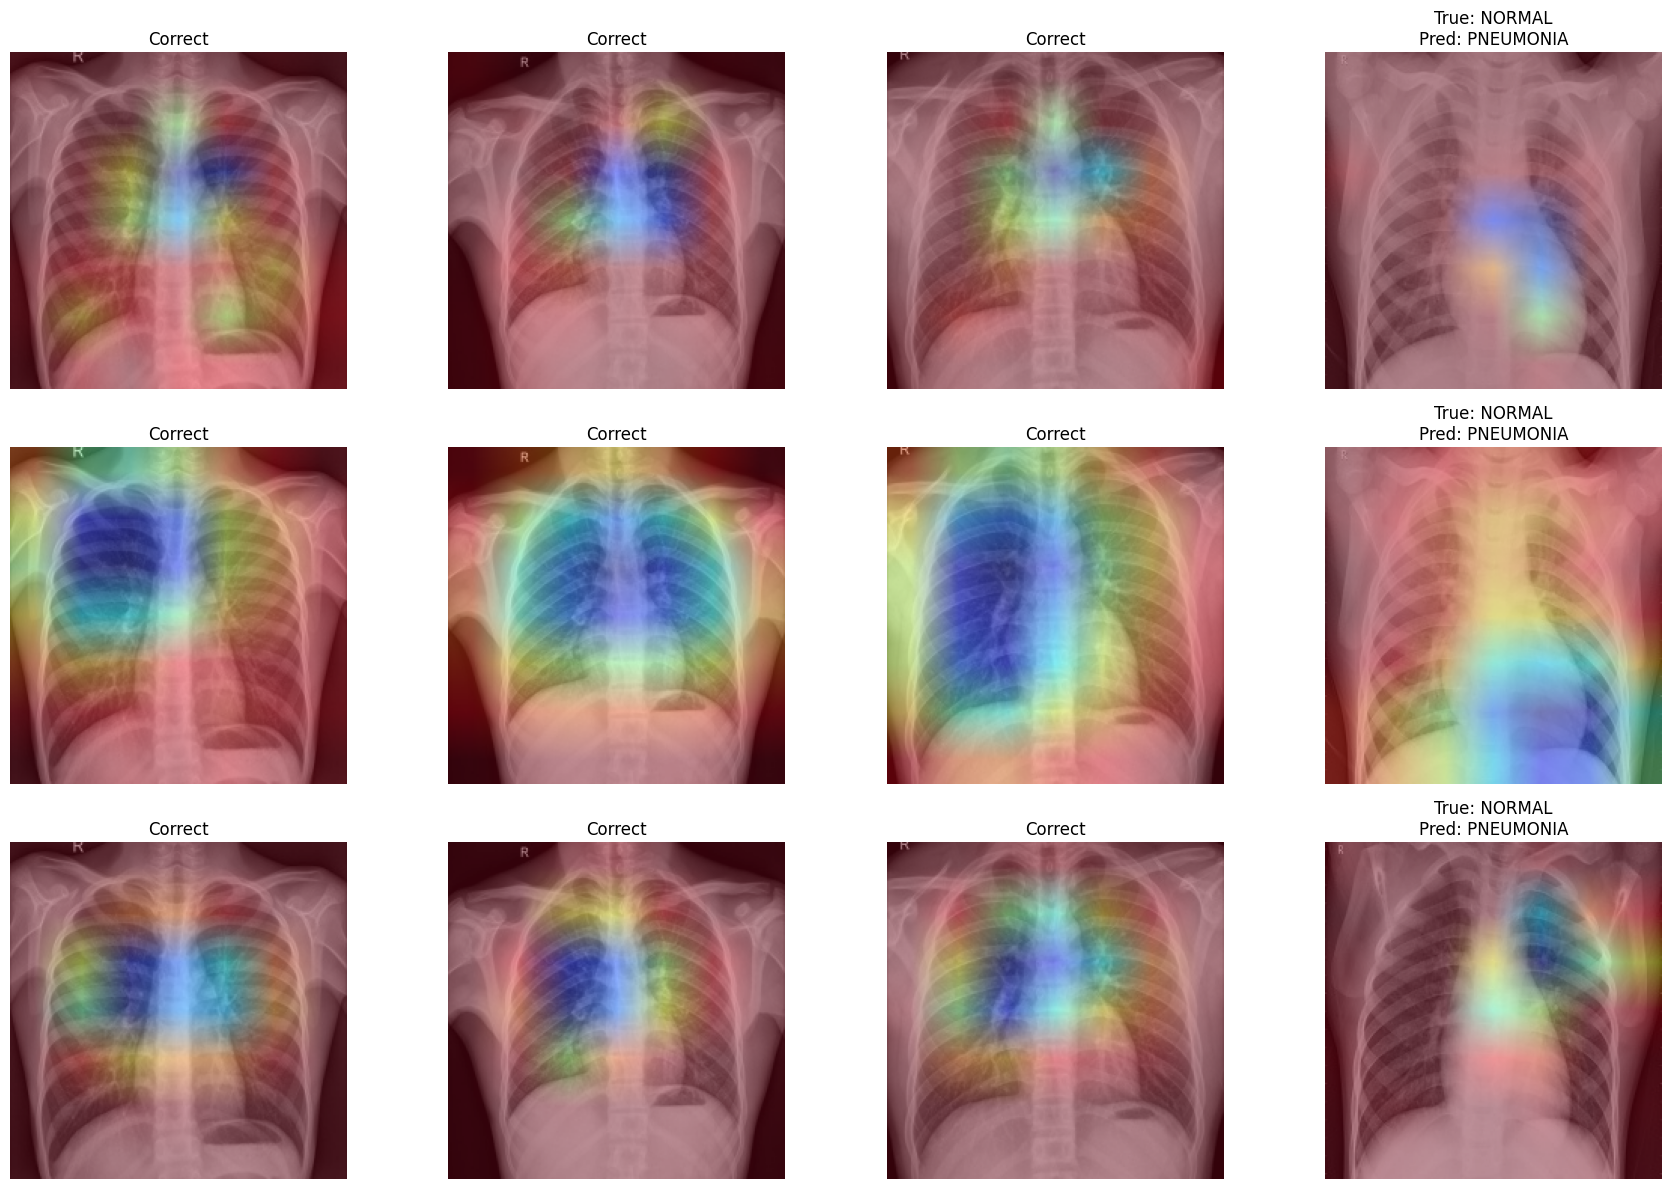

In [30]:
# ========================
# GradCAM Class
# ========================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, inp, outp):
            self.activations = outp.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, x, class_idx=None):
        out = self.model(x)
        if class_idx is None:
            class_idx = torch.argmax(out)
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


# ========================
# Hiển thị GradCAM cho 3 model
# ========================
def show_gradcam_3models(model_resnet, model_dense, model_efficient, dataloader_test, device, class_names, n_correct=3):
    models_list = [
        (model_resnet, model_resnet.layer4[-1], "ResNet50"),
        (model_dense, model_dense.features[-1], "DenseNet169"),
        (model_efficient, model_efficient.features[-1], "EfficientNet-B0")
    ]
    
    plt.figure(figsize=(18, 12))
    
    for row_idx, (model, target_layer, name) in enumerate(models_list):
        model.to(device)
        model.eval()
        gradcam = GradCAM(model, target_layer)
        
        correct_imgs, wrong_img = [], None

        for inputs, labels in dataloader_test:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(inputs.size(0)):
                if preds[i] == labels[i] and len(correct_imgs) < n_correct:
                    correct_imgs.append(inputs[i].cpu())
                if preds[i] != labels[i] and wrong_img is None:
                    wrong_img = (inputs[i].cpu(), labels[i].item(), preds[i].item())
            if len(correct_imgs) >= n_correct and wrong_img is not None:
                break

        all_imgs = correct_imgs + [wrong_img[0]]
        titles = ["Correct"]*n_correct + [f"True: {class_names[wrong_img[1]]}\nPred: {class_names[wrong_img[2]]}"]

        for col_idx, img_tensor in enumerate(all_imgs):
            x = img_tensor.unsqueeze(0).to(device)
            cam = gradcam.generate(x)

            img_np = img_tensor.permute(1,2,0).numpy()
            img_np = (img_np - img_np.min())/(img_np.max()-img_np.min())*255
            img_np = img_np.astype(np.uint8)

            heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
            heatmap = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
            overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

            plt_idx = row_idx * (n_correct+1) + col_idx + 1
            plt.subplot(len(models_list), n_correct+1, plt_idx)
            plt.imshow(overlay)
            if col_idx == 0:
                plt.ylabel(name, fontsize=12)
            plt.title(titles[col_idx])
            plt.axis("off")

    plt.tight_layout()
    plt.show()


# --- Sử dụng ---
show_gradcam_3models(model_resnet, model_dense, model_efficient, dataloaders['test'], device, class_names)


In [32]:

# ==========================================================
# File csv
# ==========================================================
resnet_train_probs = "/kaggle/working/resnet50_train_probs.csv"
densenet_train_probs = "/kaggle/working/densenet169_train_probs.csv"
effnet_train_probs = "/kaggle/working/efficientnetb0_train_probs.csv"

resnet_val_probs = "/kaggle/working/resnet50_val_probs.csv"
densenet_val_probs = "/kaggle/working/densenet169_val_probs.csv"
effnet_val_probs = "/kaggle/working/efficientnetb0_val_probs.csv"

resnet_test_probs = "/kaggle/working/resnet50_test_probs.csv"
densenet_test_probs = "/kaggle/working/densenet169_test_probs.csv"
effnet_test_probs = "/kaggle/working/efficientnetb0_test_probs.csv"

val_labels_path = "/kaggle/working/resnet50_val_labels.csv"
test_labels_path = "/kaggle/working/resnet50_test_labels.csv"

# ==========================================================
# HÀM XỬ LÝ
# ==========================================================
def get_probs(file):
    df = pd.read_csv(file, sep=None, engine='python')
    df = df.iloc[:, :2]  # chỉ giữ 2 class probabilities
    return df.to_numpy().astype(float)

def get_labels(file):
    df = pd.read_csv(file, header=None)
    labels = np.asarray(df)[:, 1]
    return labels.astype(int)

def predicting(probs):
    return np.argmax(probs, axis=1)

def evaluate_metrics(labels, preds, classes):
    print("Classification Report:")
    print(classification_report(labels, preds, target_names=classes, digits=4))
    cm = confusion_matrix(labels, preds)
    print("Confusion Matrix:\n", cm)
    print("Classwise Accuracy:", cm.diagonal() / cm.sum(axis=1))
    print("-" * 60)

def get_scores(labels, *argv):
    count = len(argv)
    metrics_mat = np.zeros((4, count))
    num_classes = len(np.unique(labels))
    for i, probs in enumerate(argv):
        preds = predicting(probs)
        if num_classes == 2:
            pre = precision_score(labels, preds)
            rec = recall_score(labels, preds)
            f1 = f1_score(labels, preds)
            auc = roc_auc_score(labels, probs[:, 1])
        else:
            pre = precision_score(labels, preds, average='macro')
            rec = recall_score(labels, preds, average='macro')
            f1 = f1_score(labels, preds, average='macro')
            auc = roc_auc_score(labels, probs, average='macro', multi_class='ovo')
        metrics_mat[:, i] = np.array([pre, rec, f1, auc])
    weights = [np.tanh(np.mean(m)) for m in metrics_mat.T]
    weights = np.array(weights) / np.sum(weights)
    print(f"Weights = {weights}")
    return weights

# ==========================================================
# CHẠY CHÍNH
# ==========================================================
res_train = get_probs(resnet_train_probs)
den_train = get_probs(densenet_train_probs)
eff_train = get_probs(effnet_train_probs)

res_val = get_probs(resnet_val_probs)
den_val = get_probs(densenet_val_probs)
eff_val = get_probs(effnet_val_probs)

res_test = get_probs(resnet_test_probs)
den_test = get_probs(densenet_test_probs)
eff_test = get_probs(effnet_test_probs)

val_labels = get_labels(val_labels_path)
test_labels = get_labels(test_labels_path)

# Lấy weights dựa trên validation
weights = get_scores(val_labels, res_val, den_val, eff_val)


# Ensemble với weighted average
ensemble_probs = weights[0]*res_test + weights[1]*den_test + weights[2]*eff_test
preds = predicting(ensemble_probs)

print("Ensemble Accuracy =", np.mean(preds == test_labels))
evaluate_metrics(test_labels, preds, ['Normal', 'Pneumonia'])


Weights = [0.3319038  0.33405186 0.33404435]
Ensemble Accuracy = 0.9886363636363636
Classification Report:
              precision    recall  f1-score   support

      Normal     0.9750    0.9832    0.9791       238
   Pneumonia     0.9938    0.9907    0.9922       642

    accuracy                         0.9886       880
   macro avg     0.9844    0.9869    0.9856       880
weighted avg     0.9887    0.9886    0.9887       880

Confusion Matrix:
 [[234   4]
 [  6 636]]
Classwise Accuracy: [0.98319328 0.99065421]
------------------------------------------------------------
